In [1]:
from MMTModules import *
from CobayaModules import *
from DetectorTimeConstantModules import *
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def bin_maps_to_1d(maps_dict, delta_ell=50, ell_max=5000, pix_size=0.25, N=1024):        
    
    N=int(N)
    # make a 2d ell coordinate system
    ones = np.ones(N)
    inds  = (np.arange(N) - N/2.) /(N-1.)
    kX = np.outer(ones,inds) / (pix_size/60. * np.pi/180.)
    kY = np.transpose(kX)
    K = np.sqrt(kX**2. + kY**2.)
    ell_scale_factor = 2. * np.pi 
    ell2d = K * ell_scale_factor
    maps_dict_keys = maps_dict.keys()
    
    # make an array to hold the power spectrum results
    N_bins = int(ell_max/delta_ell)
    ell_array = np.arange(N_bins)
    CL_array_TT = np.zeros(N_bins)
    CL_array_EE = np.zeros(N_bins)
    CL_array_BB = np.zeros(N_bins)
    CL_array_TE = np.zeros(N_bins)
    CL_array_EB = np.zeros(N_bins)
    CL_array_TB = np.zeros(N_bins)    
   
    maps_dict_squared = {}
    maps_dict_squared['TT'] = np.real(np.conj(maps_dict['TT'])*maps_dict['TT'])
    
    # fill out the spectra
    i = 0
    while (i < N_bins):
        ell_array[i] = (i + 0.5) * delta_ell
        inds_in_bin = ((ell2d >= (i* delta_ell)) * (ell2d < ((i+1)* delta_ell))).nonzero()
        CL_array_TT[i] = np.mean(maps_dict_squared['TT'][inds_in_bin])
        
        if 'TT' in maps_dict_keys and 'EE' in maps_dict_keys:
            CL_array_EE[i] = np.mean(maps_dict['EE'][inds_in_bin])
            CL_array_BB[i] = np.mean(maps_dict['BB'][inds_in_bin])
            CL_array_TE[i] = np.mean(maps_dict['TE'][inds_in_bin])
            CL_array_EB[i] = np.mean(maps_dict['EB'][inds_in_bin])
            CL_array_TB[i] = np.mean(maps_dict['TB'][inds_in_bin])
        #print i, ell_array[i], inds_in_bin, CL_array[i]
        i = i + 1
    
    Cl_spec_dict = {}
    if 'TT' in maps_dict_keys:
        Cl_spec_dict['TT'] = CL_array_TT*np.sqrt(pix_size /60.* np.pi/180.)*2.
    if 'TT' in maps_dict_keys and 'EE' in maps_dict_keys:
        Cl_spec_dict['EE'] = CL_array_EE*np.sqrt(pix_size /60.* np.pi/180.)*2.
        Cl_spec_dict['BB'] = CL_array_BB*np.sqrt(pix_size /60.* np.pi/180.)*2.
        Cl_spec_dict['TE'] = CL_array_TE*np.sqrt(pix_size /60.* np.pi/180.)*2.
        Cl_spec_dict['EB'] = CL_array_EB*np.sqrt(pix_size /60.* np.pi/180.)*2.
        Cl_spec_dict['TB'] = CL_array_TB*np.sqrt(pix_size /60.* np.pi/180.)*2.
    # return the power spectrum and ell bins
    return(ell_array,Cl_spec_dict)

In [3]:
def make_xlink_spectrum(N,pixel_size,ell_max,delta_ell,perc_err,scan_sp,tau,ell,L):
    #define 2D model
    ##define 2D coordinate system in map space
    x_1d = (np.arange(N)/N - 0.5)*L*np.pi/(180.*60.)
    y_1d = np.copy(x_1d)
    x,y = np.meshgrid(x_1d,y_1d)
    
    r = np.sqrt(x**2. + y**2.)
    exp_decay_2d = np.exp(-r/(scan_sp*tau*np.pi/180.))
    exp_decay_2d_meas = np.exp(-r/(scan_sp*tau*np.pi/180.*(1-perc_err)))
    
    tick_loc = [480, 490, 500, 510, 520, 530, 540]
    tick_label = [-7.5, -5, -2.5, 0, 2.5, 5, 7.5]

    #plt.imshow(exp_decay_2d_meas)
    #plt.xlim([480,540])
    #plt.ylim([480,540])
    #plt.colorbar(label='Normalized Amplitude')
    #plt.xticks(ticks=tick_loc, labels=tick_label)
    #plt.yticks(ticks=tick_loc, labels=tick_label)
    #plt.xlabel('arcmin')
    #plt.ylabel('arcmin')
    #plt.savefig('plots/2d_beam.png',dpi=1200)
    #plt.show()
    
    #take fft's and deconvolve
    exp_decay_2d_fft = np.fft.fftshift(np.fft.fft2(exp_decay_2d))
    exp_decay_2d_meas_fft = np.fft.fftshift(np.fft.fft2(exp_decay_2d_meas))
    exp_decay_2d_res_fft = np.zeros((N,N),dtype=complex)
    
    exp_decay_2d_res_fft = exp_decay_2d_meas_fft
        
    #bin to 1d
    maps_dict = {}
    maps_dict['TT'] = exp_decay_2d_res_fft#/exp_decay_2d_deproj_fft
    binned_ell_xlink, binned_exp_decay_2d_res = bin_maps_to_1d(maps_dict, delta_ell=delta_ell, ell_max=ell_max, pix_size=pixel_size, N=N)

    #normalize
    binned_exp_decay_2d_res['TT'] = binned_exp_decay_2d_res['TT'] / np.max(binned_exp_decay_2d_res['TT'])
    
    return(binned_ell_xlink, binned_exp_decay_2d_res['TT'])

In [4]:
#define relevant constants
N = 1020  # []: pixels in map
pixel_size = 0.25  # [arcmin/pixel]: size in arcmin of pixel
ell_max = 5000  # [ell]: maximum ell
delta_ell = 50  # [ell]: bin width for power spectra
perc_err_values = [0,0.01,0.05,0.1,0.2,0.3]  #[%]: percent the measure is off by
scan_sp = 1.  # [deg/s]: scan speed of telescope
tau = 10e-3  # [s]: time constant of detector
ell = np.arange(ell_max)  # [ell]: array of ell
L = N*pixel_size

In [5]:
T = np.empty((len(perc_err_values),int(len(ell)/delta_ell)))

i=0
while i<len(perc_err_values):
    perc_err = perc_err_values[i]
    binned_ell, binned_T = make_xlink_spectrum(N,pixel_size,ell_max,delta_ell,perc_err,scan_sp,tau,ell,L)
    T[i] = binned_T
    i+=1

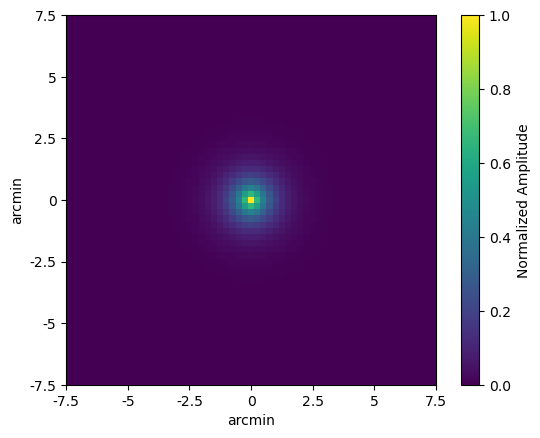

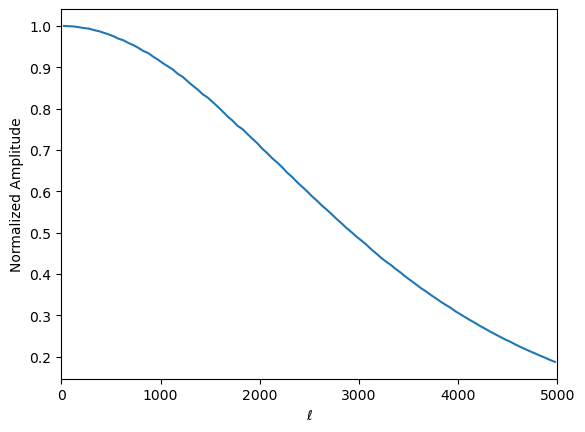

In [17]:
perc_err = 0

binned_ell, binned_T = make_xlink_spectrum(N,pixel_size,ell_max,delta_ell,perc_err,scan_sp,tau,ell,L)
plt.plot(binned_ell,binned_T)
plt.xlabel('$\ell$')
plt.ylabel('Normalized Amplitude')
plt.xlim([0,5000])
plt.savefig('plots/1d_beam.png',dpi=1200)
plt.show()

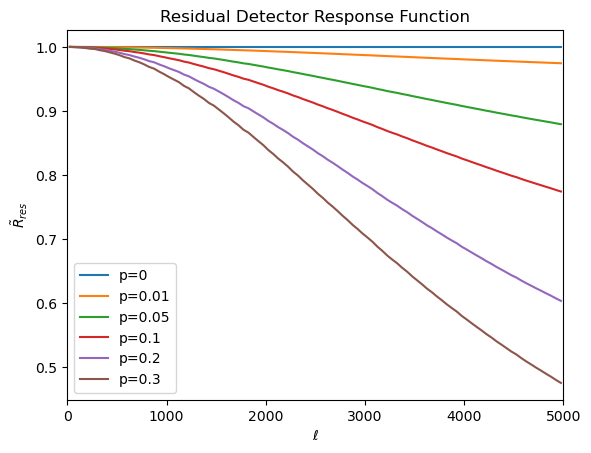

In [6]:
tau_meas = []
for p in perc_err_values:
    tau_meas.append((tau - p*tau)*1000)

i=0
while i<len(perc_err_values):
    plt.plot(binned_ell,T[0]/T[i], label = 'p='+str(perc_err_values[i]))#label='$\\tau_{meas}$='+str(np.round(tau_meas[i],2))+' ms')
    i+=1
plt.xlabel('$\ell$')
plt.ylabel('$\\tilde{R}_{res}$')
plt.title('Residual Detector Response Function')
plt.xlim([0,5000])
plt.legend()
plt.savefig('plots/det_response_func.png',dpi=1200)
plt.show()

In [7]:
#CMB power spectra for comparison
l = np.loadtxt('camb_spectra/total_cls_r_0_001.rtf',usecols=(0),dtype=str)
tt = np.loadtxt('camb_spectra/total_cls_r_0_001.rtf',usecols=(1),dtype=str)

ell = []
TT = [] 

i = 0
while i<len(tt):
    ell.append(float(l[i]))
    TT.append(float(tt[i]))
    i+=1
    
inds = np.digitize(ell,binned_ell)

binned_TT_fid = []

i=0
while i<len(binned_ell):
    to_bin = np.where(inds==i)[0]
    start = to_bin[0]
    end = to_bin[-1]+1
    binned_TT_fid.append(np.mean(TT[start:end]))
    i+=1

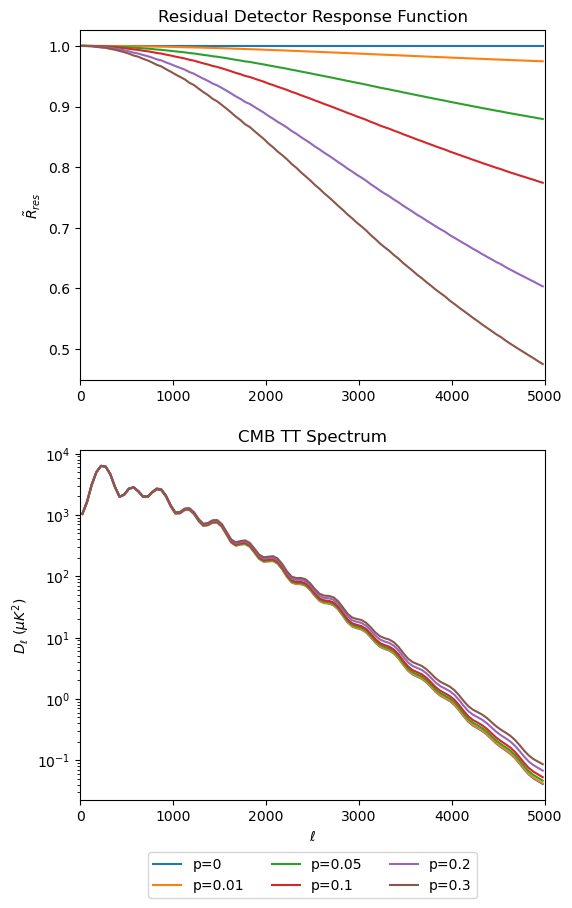

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,10))

tau_meas = []
for p in perc_err_values:
    tau_meas.append((tau - p*tau)*1000)

i=0
while i<len(perc_err_values):
    ax1.plot(binned_ell,T[0]/T[i], label = 'p='+str(perc_err_values[i]))#label='$\\tau_{meas}$='+str(np.round(tau_meas[i],2))+' ms')
    i+=1
#ax1.set_xlabel('$\ell$')
ax1.set_ylabel('$\\tilde{R}_{res}$')
ax1.set_title('Residual Detector Response Function')
ax1.set_xlim([0,5000])


tau_meas = []
for p in perc_err_values:
    tau_meas.append((tau - p*tau)*1000)

i=0
while i<len(perc_err_values):
    ax2.plot(binned_ell,T[i]*binned_TT_fid,label = 'p='+str(perc_err_values[i])) #label='$\\tau_{meas}$='+str(np.round(tau_meas[i],2))+' ms')
    i+=1
#plt.plot(binned_ell,binned_TT_fid,'--',color='gray',label='Fiducial TT')
ax2.set_yscale('log')
ax2.set_xlabel('$\ell$')
#plt.ylabel('$\ell(\ell+1)C_\ell^{\ell\ell}/2\pi$ $\mu K^2$')
ax2.set_ylabel('$D_\ell$ $(\mu K^2)$')
ax2.set_title('CMB TT Spectrum')
ax2.set_xlim([0,5000])

ax2.legend(ncols=3, loc='lower center',bbox_to_anchor=(0.5,-0.3))

#fig.subplots_adjust(hspace=0.5)

plt.savefig('plots/det_response_CMB_TT.png',dpi=1200, bbox_inches='tight')

plt.show()

In [14]:
def runCobaya(p):
    #number of sims
    num_sims = 1

    #fiducial LCDM
    ombh2_fid = 0.022
    omch2_fid = 0.12
    H0_fid = 68.0
    tau_fid = 0.07
    As_fid = 2.2e-9
    ns_fid = 0.96
    thetastar_fid = 0.010409

    #current agreed upon fiducial
    nnu_fid = 3.046

    #prior information (gaussian)
    #NOTE: This information is irrelevant when using the minimizer
    ombh2_sigma = 0.1
    omch2_sigma = 0.1
    H0_sigma = 0.1
    tau_sigma = 0.1
    As_sigma = 0.1
    ns_sigma = 0.1

    #reference distribution
    #This is where the minimizer will draw the initial points from
    perc = 0.05
    ombh2_lower = ombh2_fid*(1.-perc)
    ombh2_upper = ombh2_fid*(1.+perc)
    omch2_lower = omch2_fid*(1.-perc)
    omch2_upper = omch2_fid*(1.+perc)
    H0_lower = H0_fid*(1.-perc)
    H0_upper = H0_fid*(1.+perc)
    thetastar_lower = thetastar_fid*(1.-perc)
    thetastar_upper = thetastar_fid*(1.+perc)
    tau_lower = tau_fid*(1.-perc)
    tau_upper = tau_fid*(1.+perc)
    As_lower = As_fid*(1.-perc)
    As_upper = As_fid*(1.+perc)
    ns_lower = ns_fid*(1.-perc)
    ns_upper = ns_fid*(1.+perc)

    #reference distribution is defined as uniform over range nnu_lower -> nnu_upper and serves as the initial sample for the chain
    #the prior is a normal distribution centered at the fiducial value with some width nnu_sigma
    nnu_lower = nnu_fid*(1.-perc)
    nnu_upper = nnu_fid*(1.+perc)
    nnu_sigma = 0.06

    #end criterion for bobyqa
    rhoend_bobyqa = 0.0000001

    #Generate SO leakage spectra
    #from SO 90 GHz Case 3 parameters
    #fwhm = 2.1
    #f3db_b = 210.
    scan_sp = 1.   #deg/s
    det_tau = 10e-3    #s, nominal detector time constant
    det_tau_unc = p    #uncertainty in measuring nominal detector time constant

    ##########################################################################################################################################


    #setup cobaya simulation
    #parameters
    lmax = 5100    #for accuracy to lmax of 5000
    lmin = 10
    packages_path = '/path/to/your/packages'
    ell = np.arange(lmax+1)

    #leaks pct_leak of tt power into other spectra
    det_real = (lpf_tf_amp(ell, scan_sp, det_tau))
    det_meas = lpf_tf_amp(ell,scan_sp,det_tau*(1.-det_tau_unc))
    TF_eff = (det_real/det_meas)[lmin:lmax+1]
    TF_eff_dict = None
    print(TF_eff)

    #no transfer function bias:
    #TF_eff_dict['TTTE'] = 0.
    #TF_eff_dict['TTEE'] = 0.
    #TF_eff_dict['EE'] = pct_diff


    #calculate fiducial spectra
    Cl_fid = generate_fiducial(lmax = lmax, lmin = lmin, ombh2=ombh2_fid, omch2=omch2_fid,
                               thetastar=thetastar_fid, tau=tau_fid, As=As_fid, ns=ns_fid, nnu=nnu_fid)

    #Cl_fid['EE'] = np.zeros(len(Cl_fid['TT']))
    #Cl_fid['TE'] = np.zeros(len(Cl_fid['TT']))


    if TF_eff is not None:
        Cl_map = {}

        Cl_map['TT'] = TF_eff*Cl_fid['TT']
        Cl_map['TE'] = TF_eff*Cl_fid['TE']
        Cl_map['EE'] = TF_eff*Cl_fid['EE']

    else:
        Cl_map = Cl_fid


    #Likelihood Function
    #define gaussian likelihood
    #including TT, TE, EE in likelihood
    def my_like_multi_spectra(
            # Parameters that we may sample over (or not)
            Cl_fid=Cl_fid,
            #TF_eff = TF_mag[8:l_max-1],
            TF_eff_dict = TF_eff_dict,
            # Keyword through which the cobaya likelihood instance will be passed.
            _self=None):
        import numpy as np

        # Cl of the map: data + noise
    #    Cl_map = {}

        #WATCHOUT: watch out for redefining when looping thru pure E and pure B keys with T in front
    #    if TF_eff_dict is not None:
    #        Cl_map = {}
    #        for tf_key in TF_eff_dict.keys():
    #            if tf_key == 'pure T':
    #                this_TT = Cl_fid['TT']
    #                Cl_map['TT'] = Cl_fid['TT']
    #                Cl_map['TE'] = Cl_fid['TE'] + TF_eff_dict['pure T']['TTTE']*this_TT
    #                Cl_map['EE'] = Cl_fid['EE'] + TF_eff_dict['pure T']['TTEE']*this_TT
    #                
    #            elif tf_key == 'pure E':
    #                this_EE = Cl_fid['EE']
    #                Cl_map['TT'] = Cl_fid['TT'] + TF_eff_dict['pure E']['EETT']*this_EE
    #                Cl_map['TE'] = Cl_fid['TE'] + TF_eff_dict['pure E']['EETE']*this_EE
    #                Cl_map['EE'] = Cl_fid['EE']
    #            
    #    else:
    #        Cl_map = Cl_fid

        # Request the Cl from the provider
        # I believe what this is is a snapshot of what the theoretical spectrum is at that particular set of sampled LCDM model
        Cl_theo_tt = _self.provider.get_Cl(ell_factor=False, units="muK2")['tt'][lmin:lmax+1]
        Cl_theo_ee = _self.provider.get_Cl(ell_factor=False, units="muK2")['ee'][lmin:lmax+1]
        Cl_theo_te = _self.provider.get_Cl(ell_factor=False, units="muK2")['te'][lmin:lmax+1]

        #Cl_map['TT'] = Cl_theo_tt
        #Cl_map['EE'] = Cl_theo_ee
        #Cl_map['TE'] = Cl_theo_te

        Cl_map_theo = {}
        Cl_map_theo['TT'] = Cl_theo_tt
        Cl_map_theo['EE'] = Cl_theo_ee
        Cl_map_theo['TE'] = Cl_theo_te

        #covariance matrix is the inverse of the wishart curvature
        Y_inv = np.array( ( (2*ell[lmin:lmax+1]+1) ) / ( 2*(Cl_map['TT']*Cl_map['EE'] - Cl_map['TE']**2.)**2. ) * [[Cl_map['EE']**2., -2*Cl_map['TE']*Cl_map['EE'], Cl_map['TE']**2.],
           [-2*Cl_map['EE']*Cl_map['TE'], 2*(Cl_map['TT']*Cl_map['EE']+Cl_map['TE']**2.), -2*Cl_map['TT']*Cl_map['TE']],
          [Cl_map['TE']**2., -2*Cl_map['TE']*Cl_map['TT'],Cl_map['TT']**2.]])

        #approximating the likelihood as gaussian
        d = np.array([Cl_map['TT'], Cl_map['TE'], Cl_map['EE']])
        m = np.array([Cl_map_theo['TT'], Cl_map_theo['TE'], Cl_map_theo['EE']])
    #    d = np.array([Cl_map['EE'], Cl_map['TE'], Cl_map['TT']])
    #    m = np.array([Cl_map_theo['EE'], Cl_map_theo['TE'], Cl_map_theo['TT']])
        #for whatever reason this was not working right with np.matmul
        curv = np.array([(Y_inv[0,0]*(d-m)[0])+(Y_inv[0,1]*(d-m)[1])+(Y_inv[0,2]*(d-m)[2]), 
                       (Y_inv[1,0]*(d-m)[0])+(Y_inv[1,1]*(d-m)[1])+(Y_inv[1,2]*(d-m)[2]), 
                       (Y_inv[2,0]*(d-m)[0])+(Y_inv[2,1]*(d-m)[1])+(Y_inv[2,2]*(d-m)[2])])

        #curv = np.matmul(Cov_inv,(d-m))
    #    logp = np.sum( np.matmul(np.transpose(np.sum(d-m,axis=1)), curv) )
        logp = -np.sum((d-m)[0]*curv[0] + (d-m)[1]*curv[1] + (d-m)[2]*curv[2])

        # Set our derived parameter
        derived = {'Map_Cl_at_500': Cl_map['TT'][500]}
        return logp, derived

    #Info
    #use above leakage spectra calculation (TE,TB,EB) to bias fiducial spectra
    #TF_TE = binned_spectra['TE']
    #TF_TB = binned_spectra['TB']
    #TF_EB = binned_spectra['EB']

    #initialize
    #info = initialize_simulation(Nl=None, TF_eff=None, As_lower=1e-9, As_upper=4e-9, As_fid = 2.2e-9, ns_lower=0.9, ns_upper=1.1, ns_fid=0.96, nnu_lower=3.04, nnu_upper=3.05, nnu_fid=3.046)

    info = {
            'params': {
                # Fixed
    #            'tau': tau_fid,
    #            'thetastar':thetastar_fid,
    #            'H0':H0_fid,
    #            'mnu': 0.06,
    #            'ombh2': ombh2_fid,
    #            'omch2': omch2_fid,
    #            'As': As_fid,
    #            'ns': ns_fid,
    #            'nnu': nnu_fid,
                # Sampled
    #            'nnu': {'prior': {'min': nnu_lower, 'max': nnu_upper}, 'latex': 'nnu','ref':{'dist': 'norm', 'loc':3.046, 'scale':0.06}},
    #            'nnu':{'prior':{'min':3.03,'max':3.06},'ref':{'min':3.03,'max':3.06}, 'latex':'nnu'},
    #            'ombh2':{'prior':{'min':ombh2_lower,'max':ombh2_upper},'ref':{'min':ombh2_lower,'max':ombh2_upper},'latex':'ombh2'},
    #            'ombh2':{'prior':{'min':ombh2_lower,'max':ombh2_upper},'ref':ombh2_fid*(1.+0.02)},'latex':'ombh2'},
                'ombh2':{'prior':{'min':ombh2_lower,'max':ombh2_upper},'ref':ombh2_fid,'latex':'ombh2'},
    #            'omch2':{'prior':{'min':omch2_lower,'max':omch2_upper},'ref':omch2_fid*(1.+0.02),'latex':'omch2'},
                'omch2':{'prior':{'min':omch2_lower,'max':omch2_upper},'ref':omch2_fid,'latex':'omch2'},
    #            'H0':{'prior':{'min':H0_lower,'max':H0_upper},'ref':{'min':H0_lower,'max':H0_upper},'latex':'H0'},
    #            'tau':{'prior':{'min':tau_lower,'max':tau_upper},'ref':tau_fid*(1.+0.02),'latex':'tau'},
                'tau':{'prior':{'min':tau_lower,'max':tau_upper},'ref':tau_fid,'latex':'tau'},
    #            'thetastar':{'prior':{'min':thetastar_lower,'max':thetastar_upper},'ref':thetastar_fid*(1.+0.02),'latex':'thetastar'},
                'thetastar':{'prior':{'min':thetastar_lower,'max':thetastar_upper},'ref':thetastar_fid,'latex':'thetastar'},
    #            'As':{'prior':{'min':As_lower,'max':As_upper},'ref':As_fid*(1.+0.02),'latex':'As'},
                'As':{'prior':{'min':As_lower,'max':As_upper},'ref':As_fid,'latex':'As'},
    #            'ns':{'prior':{'min':ns_lower,'max':ns_upper},'ref':ns_fid*(1.+0.02),'latex':'ns'},
                'ns':{'prior':{'min':ns_lower,'max':ns_upper},'ref':ns_fid,'latex':'ns'},
    #            'nnu':{'prior':{'min':nnu_lower,'max':nnu_upper},'ref':nnu_fid*(1.+0.02), 'latex':'nnu'},
                'nnu':{'prior':{'min':nnu_lower,'max':nnu_upper},'ref':nnu_fid,'latex':'nnu'}},
    #            'nnu':{'prior':{'dist':'norm','loc':nnu_fid,'scale':nnu_sigma},'ref':nnu_fid,'latex':'nnu'}},

            'likelihood': {'my_cl_like': {
                "external": my_like_multi_spectra,
    #            "internal":likelihood.Likelihood.logp,
                # Declare required quantities!
                "requires": {'Cl': {'tt': lmax,'te':lmax,'ee':lmax}}}},
            'theory': {'camb': {'stop_at_error': True}},
    #        'sampler':'mcmc',
            'packages_path': packages_path}


    #calculate
    from cobaya.model import get_model
    model = get_model(info)

    # Optional: define an output driver
    from cobaya.output import get_output
    out = get_output(prefix="chains/my_model", resume=False, force=True)

    ombh2_list = []
    omch2_list = []
    tau_list = []
    thetastar_list = []
    As_list = []
    ns_list = []
    nnu_list = []
    chi2_list = []
    for i in range(num_sims):
        # Initialize the minimize sampler
        info_sampler = {"minimize": {'method':'bobyqa','ignore_prior':False,'override_bobyqa':{'rhoend':rhoend_bobyqa}}}
        from cobaya.sampler import get_sampler
        minimize = get_sampler(info_sampler, model=model,
                           packages_path=info["packages_path"])

        #run minimizer
        minimize.run()

        ombh2_list.append(minimize.products()['minimum']['ombh2'])
        omch2_list.append(minimize.products()['minimum']['omch2'])
        tau_list.append(minimize.products()['minimum']['tau'])
        As_list.append(minimize.products()['minimum']['As'])
        ns_list.append(minimize.products()['minimum']['ns'])
        thetastar_list.append(minimize.products()['minimum']['thetastar'])
        nnu_list.append(minimize.products()['minimum']['nnu'])
        chi2_list.append(minimize.products()['minimum']['chi2'])

    #print results
    print('ombh2: ' + str(ombh2_list))
    print('omch2: ' + str(omch2_list))
    print('tau: ' + str(tau_list))
    print('As: ' + str(As_list))
    print('ns: ' + str(ns_list))
    print('thetastar: ' + str(thetastar_list))
    print('nnu: ' + str(nnu_list))
    print('chi2: ' + str(chi2_list))
    
    return(nnu_list)

In [15]:
nnu = []
for p in perc_err_values:
    print('p = ',p)
    nnu.append(runCobaya(p)[0])

p =  0
[1. 1. 1. ... 1. 1. 1.]
[camb] `camb` module loaded successfully from /Users/cesileyking/anaconda3/lib/python3.11/site-packages/camb
[model] *WARNING* Theories {camb.transfers, camb} do not appear to be actually used for anything
[camb] `camb` module loaded successfully from /Users/cesileyking/anaconda3/lib/python3.11/site-packages/camb
[my_cl_like] Initialized external likelihood.
[output] Output to be read-from/written-into folder 'chains', with prefix 'my_model'
[minimize] Initializing
[minimize] Run 1/2 will start from random initial point:
[minimize] {'ombh2': 0.022, 'omch2': 0.12, 'tau': 0.07, 'thetastar': 0.010409, 'As': 2.2e-09, 'ns': 0.96, 'nnu': 3.046}
[minimize] Run 2/2 will start from random initial point:
[minimize] {'ombh2': 0.022, 'omch2': 0.12, 'tau': 0.07, 'thetastar': 0.010409, 'As': 2.2e-09, 'ns': 0.96, 'nnu': 3.046}
[prior] *WARNING* Reference pdf not defined or improper for some parameters. Using prior's sigma instead for them.
[minimize] Starting run 1/2
[m

[prior] *WARNING* Reference pdf not defined or improper for some parameters. Using prior's sigma instead for them.
[minimize] Starting run 1/2
[minimize] Run 1/2 converged.
[minimize] Starting run 2/2
[minimize] Run 2/2 converged.
[minimize] Finished successfully!
[minimize] -log(posterior) minimized to 0.260302
[minimize] Parameter values at minimum:
   weight  minuslogpost     ombh2     omch2       tau  thetastar            As        ns       nnu  minuslogprior  minuslogprior__0       chi2  chi2__my_cl_like
0     1.0      0.260302  0.021982  0.119589  0.069074   0.010409  2.194610e-09  0.959135  3.097971     -48.141218        -48.141218  96.803039         96.803039
[minimize] Full set of minima:
{'0': (0.26030178918870206, True), '1': (0.26030178918870206, True)}
ombh2: [0.021981926933306296]
omch2: [0.11958869120652997]
tau: [0.06907378124791912]
As: [2.194610450619563e-09]
ns: [0.9591354342826062]
thetastar: [0.01040925427672351]
nnu: [3.097970669039996]
chi2: [96.80303903596388]
p

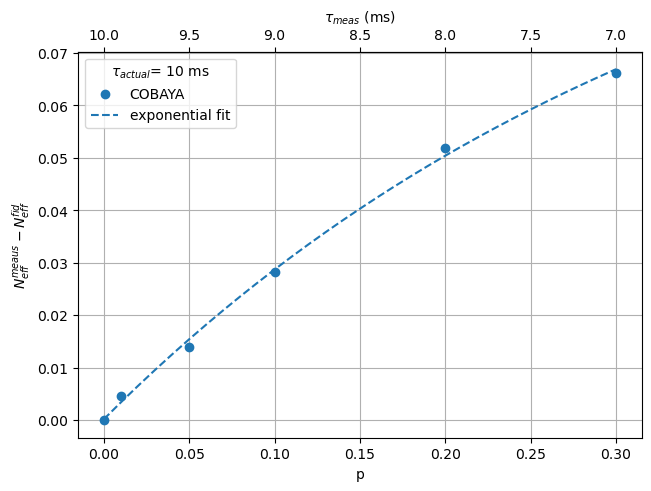

In [17]:
tau_meas = []
for p in perc_err_values:
    tau_meas.append((tau - p*tau)*1000)
    
N_eff_meas = nnu
N_eff = 3.046

N_eff_diff = []
N_eff_ratio = []
for N in N_eff_meas:
    N_eff_diff.append(N-N_eff)
    N_eff_ratio.append(N/N_eff)
    
from scipy.optimize import curve_fit

def exponential_func(x, a, b, c):
    return a * np.exp(b * x) + c

popt, pcov = curve_fit(exponential_func, perc_err_values, N_eff_diff,p0=(-1,-0.25,1))

vals = np.arange(0,0.31,0.01)


fig, ax = plt.subplots(layout='constrained')


ax.plot(perc_err_values,N_eff_diff,'o',color='tab:blue',label='COBAYA')
ax.plot(vals,exponential_func(vals,popt[0],popt[1],popt[2]),'--',color='tab:blue',label='exponential fit')
ax.set_xlabel('p')
sec_ax = ax.secondary_xaxis('top', functions=(lambda x: 10-(x*10), lambda x: 10-(x*10)) )
sec_ax.set_xlabel('$\\tau_{meas}$ (ms)')
ax.set_ylabel('$N^{meaus}_{eff}-N^{fid}_{eff}$')
plt.grid(which='both')
plt.legend(title='$\\tau_{actual}$= 10 ms')
plt.savefig('plots/tau_vs_Neff_new.png',dpi=1200)
plt.show()
